Epoch: 0 loss value: 0.1946
Epoch: 1 loss value: 0.0530
Epoch: 2 loss value: 0.0078
Epoch: 3 loss value: 0.1178
Epoch: 4 loss value: 0.0092
Epoch: 5 loss value: 0.0144
Epoch: 6 loss value: 0.0143
Epoch: 7 loss value: 0.0311
Epoch: 8 loss value: 0.0541
Epoch: 9 loss value: 0.0962


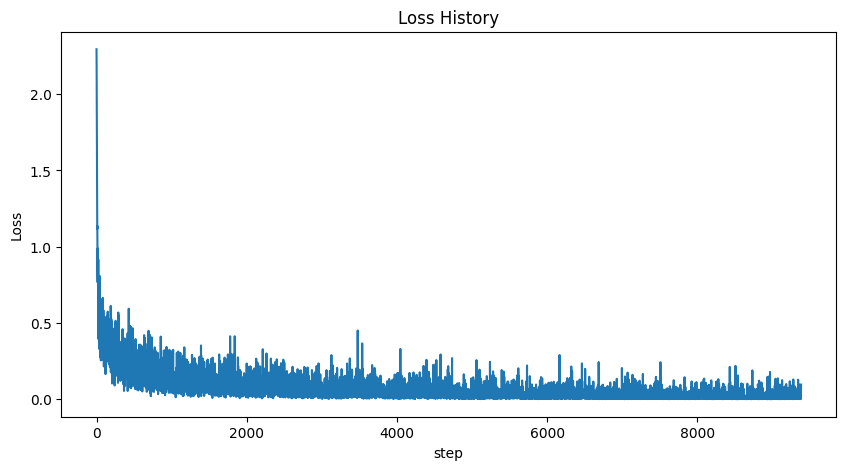

Batch Accuracy: 0.9790
Overall Accuracy: 0.9787


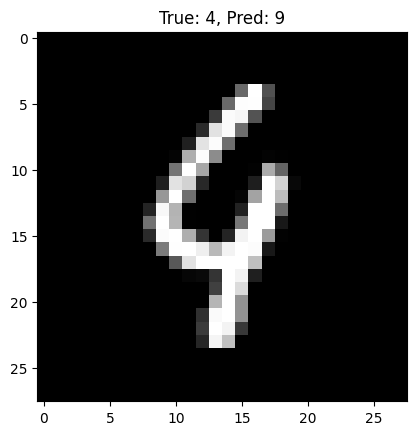

Predicted probabilities: [7.4741223e-07 3.0658057e-07 3.4416064e-06 4.0766422e-06 9.7385474e-02
 9.4132574e-06 1.5424511e-04 2.8982060e-06 1.6514181e-05 9.0242279e-01]


In [17]:
import torch
import torch.nn as nn

from torchvision import datasets, transforms
from matplotlib import pyplot as plt

### Define a transform to normalize the data
transform = transforms.Compose([
    transforms.ToTensor(), # casting everything to be a tensor
    transforms.Normalize((0.1307,), (0.3081,)) # shifts the center or mean of the data. 
]) # the numbers are the mean and standard deviation


train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform) 
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1000, shuffle=False) # no need to shuffle


class SimpleNN(nn.Module):
    def __init__(self): # constructor of the class
        super(SimpleNN, self).__init__()

        # input layer to hidden layer
        self.l1 = nn.Linear(28*28, 128) # linear transformation
        # inside are the dimensions

        # activation function
        self.relu = nn.ReLU()
        
        # hidden layer to output layer
        self.l2 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.reshape(-1, 784) # -1 automatically figures out what it should be
        # no need to remember the batch size

        output1 = self.l1(x)
        input_2 = self.relu(output1)
        output2 = self.l2(input_2)
        return output2

mynetwork = SimpleNN()


# Define a loss function
loss = torch.nn.CrossEntropyLoss() # function handle

# Perform one optim step w
optim = torch.optim.Adam(mynetwork.parameters(), lr = 0.001) # improves losses through small batches


# training
loss_history = []
num_epoch = 10
for epoch in range(num_epoch):
    for step, (images, labels) in enumerate(train_loader):

        output = mynetwork(images)
        loss_value = loss(output, labels)
        loss_history.append(loss_value.item())
        optim.zero_grad()
        loss_value.backward()
        optim.step()
    print(f"Epoch: {epoch} loss value: {loss_value.item():.4f}")

# create a loss_history line plot

plt.figure(figsize=(10, 5))
plt.plot(loss_history)
plt.xlabel("step")
plt.ylabel("Loss")
plt.title("Loss History")
plt.show()


# calculates the accuracy of a test batch by counting correct predictions
# and dividing by the total number of predictions
test_images, test_labels = next(iter(test_loader))
def get_accuracy(model, test_images, test_labels):
        correct_count = 0
        for index, image in enumerate(test_images):
                predictions = model(image)
                prob = nn.functional.softmax(predictions, dim=1)
                if (prob.argmax() == test_labels[index]):
                  correct_count += 1
        return correct_count / len(test_labels)

accuracy = get_accuracy(mynetwork, test_images, test_labels)
print(f"Batch Accuracy: {accuracy:.4f}")

# accuracy of test set
def get_all_accuracy(model, test_loader):
        correct_count = 0
        total_count = 0
        for images, labels in test_loader:
                predictions = model(images)
                prob = nn.functional.softmax(predictions, dim=1)
                correct_count += (prob.argmax(dim=1) == labels).sum().item()
                total_count += labels.size(0)
        return correct_count / total_count

all_accuracy = get_all_accuracy(mynetwork, test_loader)
print(f"Overall Accuracy: {all_accuracy:.4f}")

# try to find an image that is misclassified and plot it
def find_misclassified(model, test_loader):
        for images, labels in test_loader:
                predictions = model(images)
                prob = nn.functional.softmax(predictions, dim=1)
                pred_class = prob.argmax(dim=1)
                incorrect = (prob.argmax(dim=1) != labels).nonzero(as_tuple=True)[0] # gives the indices of the misclassified images
                if len(incorrect) > 0: # if there are any misclassified images in the batch
                        return images[incorrect[0]], labels[incorrect[0]], pred_class[incorrect[0]], prob[incorrect[0]]

misclassified, true_label, predicted_class, predicted_prob = find_misclassified(mynetwork, test_loader)

plt.imshow(misclassified.squeeze(), cmap='gray')
plt.title(f"True: {true_label.item()}, Pred: {predicted_class.item()}")
plt.show()

print("Predicted probabilities:", predicted_prob.detach().numpy())